# The Logistic Equation

---


2When dealing with populations, density-dependent[^1] and density-independent[^2] factors may both apply when studying what impacts the regulation of a population. However, since it is easier to model with density-dependent population we shall start here. 

Let's consider a per capita growth rate that decreases linearly with population size:

$$
\frac{1}{N} \frac{dN}{dt} = r \left(1 - \frac{N}{K}\right) \tag{1.1}
$$

Where:
- $t$ is time
- $N$ is the population size.
- $r$ is the intrinsic rate of growth[^3]
- $K$ is the carrying capacity[^4]

We can see that when $N \approx K$ we have that, $\frac{N}{K} = 1$, substituting this into $(1.1)$ gives:

$$
\frac{1}{N} \frac{dN}{dt} = r(1 - 1) = 0 \Rightarrow \frac{dN}{dt} = 0 \tag{1.2}
$$

Thus we can see that the rate of change of population size when $N \approx K$ is $0$ which is to be expected.

Now, let us find the closed form solution of $(1.1)$ using integration.

First, we rewrite $(1.1)$ as follows:

$$
\frac{1}{N(1-\frac{N}{K})} \frac{dN}{dt} = r \tag{1.3}
$$

Notice that $1 - \frac{N}{k} = \frac{K-N}{K}$, substituting this into $(1.3)$ gives us:

$$
\frac{K}{N(K-N)}\frac{dN}{dt} = r \tag{1.4}
$$

Before integrating, we need must find the partial fractions of $\frac{1}{N(1-\frac{N}{K})} = \frac{1}{N} + \frac{1}{K-N}$. 

Substituting what we have just found into $(1.4)$ gives us:

$$
(\frac{1}{N} + \frac{1}{K-N}) \frac{dN}{dt} = r \tag{1.5}
$$

Now, we can integrate both sides of $(1.5) with respect to $t$:

$$
\int (\frac{1}{N} + \frac{1}{K-N})\frac{dN}{dt} dt = \int \frac{1}{N} + \frac{1}{K-N} dN = \int r dt \tag{1.6}
$$

Which gives us:

$$
\ln{(N)} - \ln{(K-N)} = rt + C \quad where \quad C \in \mathbb{R} \tag{1.7}
$$

The closed form solution is of the form $N(t)$, so we need to make $N$ the subject of the formula for $(1.7)$

$$
\ln{(N)} - \ln{(K-N)} = \ln{(\frac{N}{K-N})} = rt + C \Rightarrow \frac{N}{N-K} = e^{rt + C} \tag{1.8}
$$

From $(1.8)$ it follows that:

$$
N(t) = (K-N)e^{rt+C} \Rightarrow N(1+e^{rt+C}) = Ke^{rt+C} \Rightarrow N = \frac{Ke^{rt+C}}{1+e^{rt+C}} \tag{1.9}
$$

With some rearranging of $(1.9)$ we have that:

$$
N(t) = \frac{K}{1+e^{-rt+C}} \tag{1.10}
$$

We are almost done, we now need to find C, we do this by evaluating $N(0) = N_{0}$

$$
N_{0} = \frac{K}{1 + (e^{-r\cdot 0}) \cdot e^{C}} = \frac{K}{1+e^{C}} \Rightarrow e^{C} = \frac{K}{N_{0}} - 1 \tag{1.11}
$$

We now substitute our findings from $(1.11)$ into $(1.10)$, which gives us the closed form solution for the logistic equation:

$$
N(t) = \frac{K}{1 + (\frac{K}{N_{0}}-1)e^{-rt}} \tag{1.12}
$$


[^1]: The population is regulated by biotic factors. For example, competition and disease. We call it density-dependent since density has an effect on the regulation of the population. An example is if an area is very dense with animals, a disease can easily spread between the animals.

[^2]: The population is regulated by external events such as weather and natural disasters. We call it density-independent because density has no effect on the regulation of the population. As an example, let us consider a group of moths living in a woodland area and a sudden forest fire spreads into their area. If there are 50 moths living there, the forest fire and smoke will cause most of them to die. But, if there were 5000 moths living in this area, the fire will burn with the exact same heat and speed, and will kill the same high percentage of them. It is important to note that the fire doesn't burn faster or hotter because there are more of them, thus this is independent of density. (In reality, larger population spread out over a wider area may experience a lower death count from a fire. Here we start to see what actually happens in the real world: a complex mix of density independent and dependent factors that can affect a population)

[^3]: The intrinsic rate of growth is defined as $r \equiv b - d$, where $b$ is the per capita birth rate, and $d$ is the per capita death rate. 

[^4]: The carrying capacity is the number of individuals in a specific species given that an environment can support them sustainably over time without damaging the habitat.

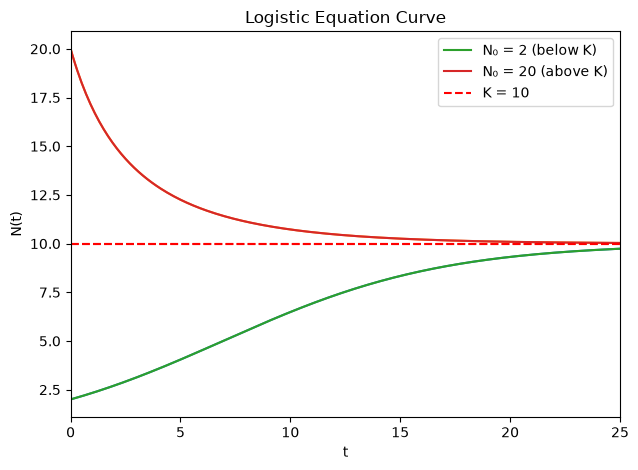

In [2]:
import matplotlib.pyplot as plt 
import numpy as np 


K = 10 #carrying capacity
r = 0.2 #intrinsic rate of growth

def N(t, N_0): #solution of the logistic equation
    output = K/(1+(K/N_0 - 1)*np.exp(-r*t))
    return output

t1 = np.arange(0.000001, 25.1, 0.1)

N1 = N(t1, N_0=2) #N_0 < K
N2 = N(t1, N_0=20) #N_0 > K

plt.plot(t1, N1)
plt.plot(t1,N2)
plt.axhline(y=K, linestyle='dashed', color='r')

plt.xlabel('t')
plt.ylabel('N(t)')
plt.title('Logistic Equation Curve')
plt.tight_layout()
plt.xlim(0, max(t1))
plt.plot(t1, N1, label=f'N₀ = 2 (below K)')
plt.plot(t1, N2, label=f'N₀ = 20 (above K)')
plt.axhline(y=K, linestyle='dashed', color='r', label=f'K = {K}')
plt.legend()

plt.show()


